In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
df=pd.read_csv("/content/cars_fuel_efficiency_clean.csv")
df

,trip_id,car_name,vehicle_type,fuel_type,trip_category,distance_km,trip_duration_hr,avg_speed_kmph,base_mileage_kmpl,actual_mileage_kmpl,mileage_delta_kmpl,fuel_consumed_L,fuel_cost_usd,cost_per_km_usd,co2_emissions_kg,co2_per_km,relative_efficiency,efficiency_band
0,1,Lexus ES,Luxury,Diesel,Very Long (>400 km),437.85,4.84,90.51,11.31,11.24,-0.07,38.96,44.59,0.1018,104.413,0.2385,0.5979,Average
1,2,Lexus ES,Luxury,Petrol,Medium (50–200 km),181.86,3.54,51.43,9.98,9.61,-0.37,18.92,23.93,0.1316,43.705,0.2403,0.5113,Poor
2,3,Audi A6,Luxury,Petrol,Medium (50–200 km),118.07,1.46,80.62,11.06,11.24,0.18,10.50,13.28,0.1125,24.255,0.2054,0.5982,Average
3,4,Maruti Swift,Hatchback,Diesel,Long (200–400 km),343.16,4.72,72.65,21.17,19.65,-1.52,17.46,19.98,0.0582,46.793,0.1364,0.7181,Average
4,5,Hyundai Creta,SUV,Diesel,Long (200–400 km),371.03,3.87,95.78,13.01,12.39,-0.62,29.95,34.28,0.0924,80.266,0.2163,0.5717,Average
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,596,Tata Tiago,Hatchback,Diesel,Medium (50–200 km),113.18,1.36,82.93,18.53,17.05,-1.48,6.64,7.60,0.0671,17.795,0.1572,0.6227,Average
596,597,Honda Brio,Hatchback,Diesel,Long (200–400 km),226.13,2.91,77.66,19.89,21.35,1.46,10.59,12.12,0.0536,28.381,0.1255,0.7801,Good
597,598,Audi A6,Luxury,Petrol,Medium (50–200 km),60.02,0.53,114.28,8.96,8.83,-0.13,6.80,8.60,0.1433,15.708,0.2617,0.4696,Poor
598,599,Maruti Swift,Hatchback,Diesel,Very Long (>400 km),414.00,7.03,58.91,21.65,20.97,-0.68,19.74,22.59,0.0546,52.903,0.1278,0.7662,Good


In [7]:
X = df.drop(['efficiency_band', 'trip_id', 'car_name'], axis=1)
y = df['efficiency_band']

In [15]:
x=pd.get_dummies(X)

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [17]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=10)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=10)

In [19]:
knn.score(x_test,y_test)

0.55

Plot Confusion Matrix

In [24]:
from sklearn.metrics import confusion_matrix
y_pred=knn.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
cm

array([[61,  0,  6,  0],
       [ 8,  0,  4,  0],
       [24,  0,  5,  0],
       [12,  0,  0,  0]])

Text(50.722222222222214, 0.5, 'Truth')

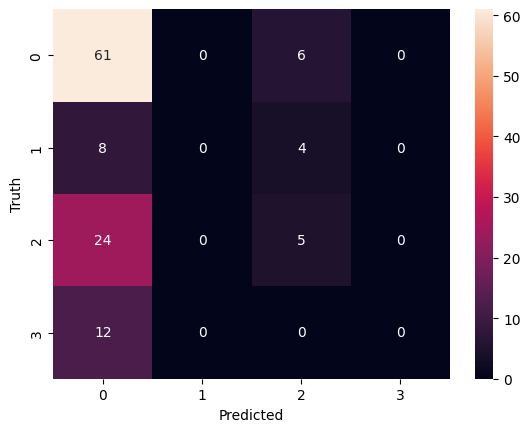

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

 classification report

In [25]:
from sklearn.metrics import classification_report
classification_report(y_test,y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


'              precision    recall  f1-score   support\n\n     Average       0.58      0.91      0.71        67\n   Excellent       0.00      0.00      0.00        12\n        Good       0.33      0.17      0.23        29\n        Poor       0.00      0.00      0.00        12\n\n    accuracy                           0.55       120\n   macro avg       0.23      0.27      0.23       120\nweighted avg       0.40      0.55      0.45       120\n'